**Generated notebook:** cell outputs have been cleared. Any summary quoted below comes from saved experiment artifacts, not a fresh execution of this source. Restore the original inputs and run the experiment driver before executing the notebook. See README.md for provenance and review limitations.

# Portfolio optimization — unified experimental comparison

## TL;DR

All five primary strategies are compared on identical daily returns and the same test window. This notebook reconciles saved results, separates predictive improvements from portfolio improvements, and develops a defensible article narrative without assuming that complexity must win.

**Saved observed result:** Equal weighting earns the highest return and Sharpe ratio but with materially higher volatility. Among the optimized portfolios, the quality and CatBoost layers improve realized return, risk, turnover and breadth relative to the regime-only specification; their marginal effects remain small and should be interpreted with paired uncertainty and explanatory controls.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "portfolio-mpl"))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The universe contains **all 323 tickers** in the dated source snapshot with exactly one finite, positive adjusted close on each of its 6,573 dates. No alphabetical truncation is used. Historical delistings and time-varying index membership are still unavailable, so **survivorship and universe-selection bias remain**; the sample is a complete-history US large-cap panel, not a reconstructed constituent universe.
6. The 2021–2026 period is not used to select the frozen quality or CatBoost hyperparameters. Annual walk-forward refits may use only matured observations from earlier test dates, which is valid real-time updating. Because the original project had previously displayed this period, the study is best read as a transparent exploratory extension rather than a preregistered replication.

## Data

### Load executed results and their frozen provenance

In [2]:
spec = json.loads((ROOT / "artifacts/frozen_spec.json").read_text())
manifest = json.loads((ROOT / "artifacts/run_manifest.json").read_text())
assert spec["code_hashes"] == code_hashes(), "Implementation differs from the frozen experiment."
prices, returns, splits, split_summary, price_hashes = load_prices()
assert spec["input_hashes"] == price_hashes
results = {name: load_result(name, "test") for name in LABELS}
validation_results = {name: load_result(name, "validation") for name in LABELS}
for result in results.values():
    validate_result(result)
    assert result.returns.index.equals(splits["test"])
test_table = metric_table(results)
validation_table = metric_table(validation_results)
display(split_summary)
display(pd.DataFrame({"parameter": ["Quality strength", "CatBoost depth", "Trees", "ML risk strength", "Test days"],
                      "value": [spec["quality_strength"], spec["ml"]["depth"], spec["ml"]["iterations"], spec["ml"]["ml_strength"], len(splits["test"])]}))
print("All strategies share", len(splits["test"]), "test observations and", len(results["baseline"].target_weights), "rebalance dates.")

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,323,1381471
validation,2017-01-03,2020-12-31,1007,323,325261
test,2021-01-04,2026-02-20,1289,323,416347


,parameter,value
0,Quality strength,0.50
1,CatBoost depth,4.00
2,Trees,300.00
3,ML risk strength,0.25
4,Test days,1289.00


### Reconcile compact tables to full daily artifacts

Metrics are recomputed from stored daily paths and weights. The comparison refuses stale or mismatched source prices, code versions or dates. Company-quality exposure is calculated below directly from the common fundamental panel; it is not needed by the price-only control notebooks.

In [3]:
recorded = pd.read_csv(ROOT / "artifacts/tables/test_metrics.csv", index_col=0)
reconcile_columns = [x for x in recorded.columns if x != "Average Portfolio Quality"]
error = (test_table[reconcile_columns] - recorded[reconcile_columns]).abs().max().max()
assert error < 1e-9
print("Maximum absolute reconciliation error:", error)
print("Empirical tail sample sizes:", {"95%": int(np.ceil(len(splits["test"])*.05)), "99%": int(np.ceil(len(splits["test"])*.01))})
print("Data selection caveat:", spec["historical_test_exposure"])

## Results

### Validation development results

These observations were used to choose the new layer strengths. They are not independent evidence of superiority.

In [4]:
display(styled(validation_table[METRIC_COLUMNS]))

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,16.02%,20.99%,0.814,1.127,37.23%,3.33%,6.28%,0.821,323.000
baseline,11.87%,15.75%,0.791,1.118,28.76%,2.37%,4.95%,5.457,21.446
pipeline1,11.85%,15.78%,0.789,1.117,28.63%,2.37%,4.95%,5.893,19.615
pipeline2,12.86%,15.74%,0.848,1.194,28.61%,2.39%,4.97%,5.119,30.281
pipeline3,12.87%,15.73%,0.848,1.194,28.72%,2.39%,4.98%,4.981,32.612


### Main test table

CAGR and volatility are annualized; CVaR is a daily loss magnitude. All values are net of the same 10 bps trading-cost model.

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,14.08%,15.95%,0.906,1.327,19.35%,2.24%,3.53%,0.818,323.000
baseline,7.45%,11.59%,0.678,0.955,20.61%,1.66%,2.65%,5.609,22.850
pipeline1,7.55%,11.58%,0.687,0.969,20.72%,1.66%,2.63%,5.946,21.859
pipeline2,7.88%,11.52%,0.716,1.012,19.23%,1.64%,2.61%,5.182,32.038
pipeline3,7.91%,11.49%,0.720,1.018,18.91%,1.64%,2.61%,5.034,34.108


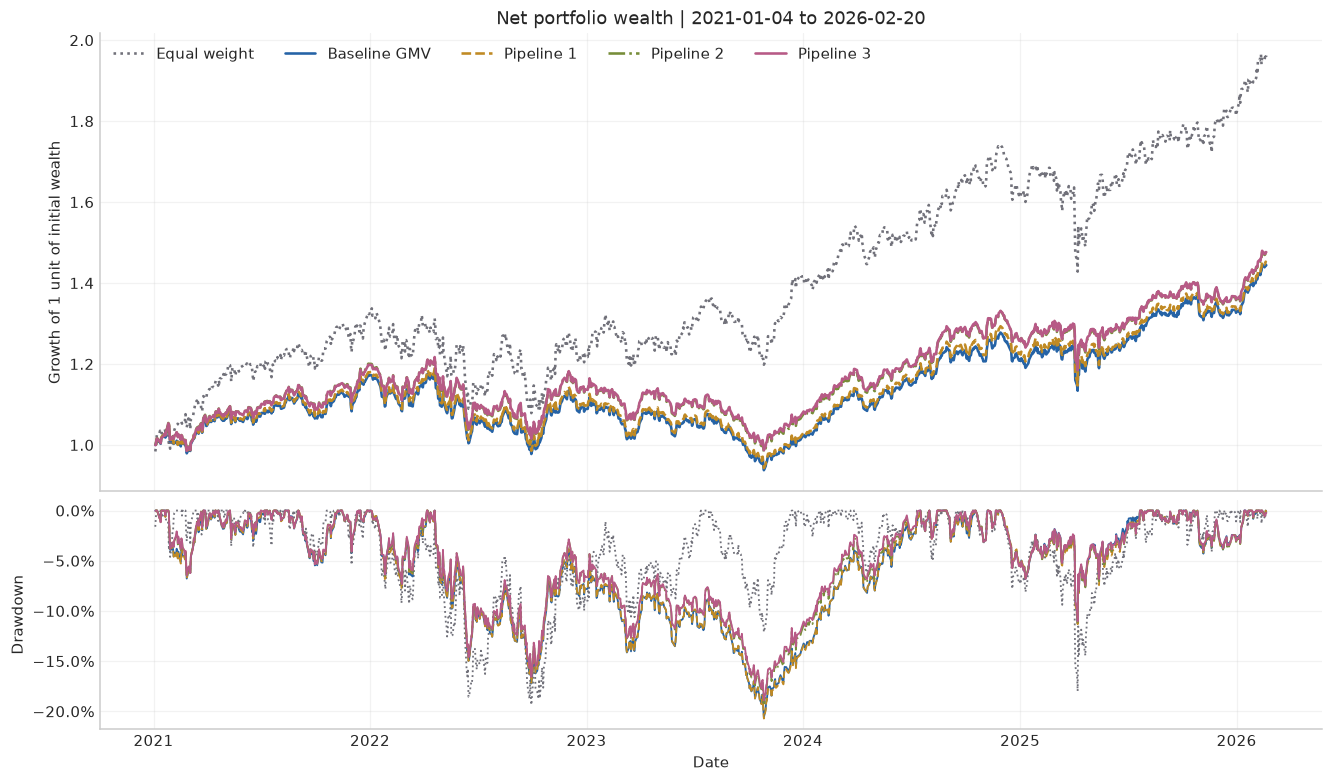

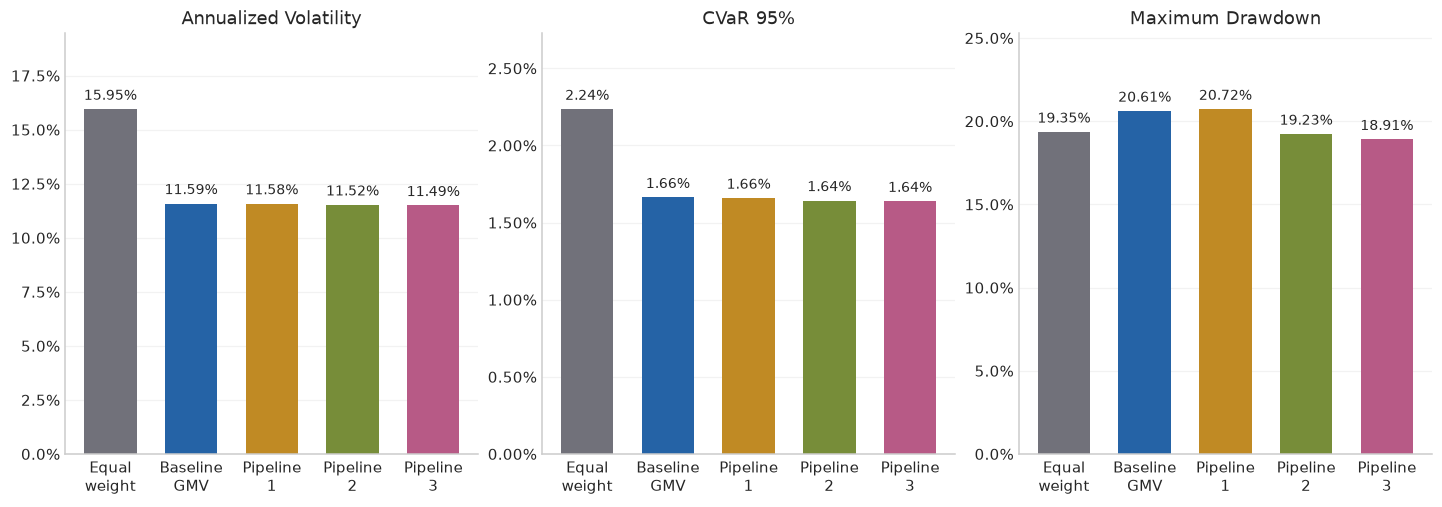

In [5]:
display(styled(test_table[METRIC_COLUMNS]))
test_table.to_csv(ROOT / "artifacts/tables/comparison_recomputed_test_metrics.csv")
performance_plot(results, "comparison_test_performance")
risk_plot(test_table, "comparison_test_risk")

### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

In [6]:
display(styled(test_table[["Cumulative Return", "VaR 95%", "VaR 99%", "Calmar", "Drawdown Duration", "Total Transaction Costs", "Average HHI", "Average Active Positions", "Average Maximum Weight", "Mean Target L1 Change", "Solver Failures", "HMM Fallbacks"]]))

,Cumulative Return,VaR 95%,VaR 99%,Calmar,Drawdown Duration,Total Transaction Costs,Average HHI,Average Active Positions,Average Maximum Weight,Mean Target L1 Change,Solver Failures,HMM Fallbacks
equal_weight,96.21%,1.52%,2.62%,0.728,380.000,0.42%,0.31%,323.000,0.31%,0.000,0.000,0.000
baseline,44.40%,1.17%,1.89%,0.361,560.000,2.87%,4.88%,41.806,9.59%,0.451,0.000,0.000
pipeline1,45.11%,1.16%,1.90%,0.364,560.000,3.04%,5.06%,39.919,9.95%,0.480,0.000,0.000
pipeline2,47.42%,1.18%,1.90%,0.410,559.000,2.65%,3.37%,56.032,6.91%,0.416,0.000,0.000
pipeline3,47.63%,1.17%,1.90%,0.419,559.000,2.57%,3.18%,59.694,6.57%,0.404,0.000,0.000


### Incremental changes: does each added layer help?

Negative changes favor the newer strategy for risk, costs and concentration; positive changes favor it for returns and effective breadth. The separate equal-weight reference answers whether optimization adds value relative to naive diversification.

In [7]:
pairs = [("baseline", "pipeline1"), ("pipeline1", "pipeline2"), ("pipeline2", "pipeline3")]
incremental = pd.DataFrame({f"{LABELS[b]} minus {LABELS[a]}": test_table.loc[b, METRIC_COLUMNS]-test_table.loc[a, METRIC_COLUMNS] for a,b in pairs}).T
display(styled(incremental))
incremental.to_csv(ROOT / "artifacts/tables/test_incremental_differences.csv")

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
Pipeline 1 minus Baseline GMV,0.10%,-0.01%,0.009,0.013,0.11%,-0.00%,-0.02%,0.337,-0.991
Pipeline 2 minus Pipeline 1,0.33%,-0.05%,0.029,0.043,-1.50%,-0.02%,-0.02%,-0.764,10.178
Pipeline 3 minus Pipeline 2,0.03%,-0.03%,0.004,0.006,-0.32%,-0.00%,0.00%,-0.149,2.070


### Statistical uncertainty and block-length sensitivity

Paired blocks use the same sampled dates for both strategies. These 95% intervals condition on the selected strategies and this dataset. They do not correct for repeated model search, familywise comparisons, survivorship bias or an already exposed test. Bootstrap drawdown intervals are especially sensitive to synthetic block ordering.

In [8]:
bootstrap = pd.read_csv(ROOT / "artifacts/tables/test_paired_bootstrap.csv")
primary_ci = bootstrap[bootstrap.block_length.eq(20)].copy()
primary_ci["excludes_zero"] = (primary_ci.lower_95 > 0) | (primary_ci.upper_95 < 0)
display(primary_ci.set_index(["reference", "experiment", "metric"])[["difference", "lower_95", "upper_95", "excludes_zero"]])
block_sensitivity = bootstrap[bootstrap.metric.eq("Annualized Volatility")].set_index(["reference", "experiment", "block_length"])
display(block_sensitivity[["difference", "lower_95", "upper_95"]])

difference  lower_95  upper_95  \
reference experiment metric                                                  
baseline  pipeline1  Annualized Volatility   -0.000087 -0.000603  0.000333   
                     CVaR 95%                -0.000047 -0.000273  0.000145   
                     Maximum Drawdown         0.001118 -0.009244  0.008444   
                     Sharpe                   0.008759 -0.037866  0.050635   
pipeline1 pipeline2  Annualized Volatility   -0.000538 -0.001387  0.000239   
                     CVaR 95%                -0.000156 -0.000447  0.000132   
                     Maximum Drawdown        -0.014963 -0.029249  0.011329   
                     Sharpe                   0.029488 -0.063863  0.124492   
pipeline2 pipeline3  Annualized Volatility   -0.000282 -0.000435 -0.000130   
                     CVaR 95%                -0.000049 -0.000189  0.000098   
                     Maximum Drawdown        -0.003175 -0.005825  0.002017   
                     Sharpe                   0.003883 -0.013006  0.021532   
baseline  pipeline2  Annualized Volatility   -0.000626 -0.001414  0.000043   
                     CVaR 95%                -0.000203 -0.000500  0.000063   
                     Maximum Drawdown        -0.013845 -0.029920  0.010707   
                     Sharpe                   0.038247 -0.055579  0.129283   
          pipeline3  Annualized Volatility   -0.000907 -0.001771 -0.000187   
                     CVaR 95%                -0.000252 -0.000556  0.000035   
                     Maximum Drawdown        -0.017020 -0.034063  0.010196   
                     Sharpe                   0.042130 -0.057322  0.141747   

                                            excludes_zero  
reference experiment metric                                
baseline  pipeline1  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
pipeline1 pipeline2  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
pipeline2 pipeline3  Annualized Volatility           True  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
baseline  pipeline2  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
          pipeline3  Annualized Volatility           True  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False

difference  lower_95  upper_95
reference experiment block_length                                
baseline  pipeline1  10             -0.000087 -0.000581  0.000328
                     20             -0.000087 -0.000603  0.000333
                     60             -0.000087 -0.000484  0.000289
pipeline1 pipeline2  10             -0.000538 -0.001393  0.000269
                     20             -0.000538 -0.001387  0.000239
                     60             -0.000538 -0.001275  0.000318
pipeline2 pipeline3  10             -0.000282 -0.000435 -0.000139
                     20             -0.000282 -0.000435 -0.000130
                     60             -0.000282 -0.000420 -0.000139
baseline  pipeline2  10             -0.000626 -0.001400  0.000086
                     20             -0.000626 -0.001414  0.000043
                     60             -0.000626 -0.001344  0.000167
          pipeline3  10             -0.000907 -0.001762 -0.000159
                     20             -0.000907 -0.001771 -0.000187
                     60             -0.000907 -0.001720 -0.000020

### Results by calendar year

The 2026 row contains only observations through February 20. Its period return is not annualized and must not be compared as a full-year return.

strategy,baseline,equal_weight,pipeline1,pipeline2,pipeline3
year,,,,,
2021,17.22%,32.48%,17.96%,20.04%,19.80%
2022,-7.14%,-8.07%,-6.99%,-5.41%,-5.08%
2023,-6.61%,16.25%,-6.76%,-5.91%,-5.55%
2024,19.13%,14.42%,19.98%,17.94%,17.34%
2025,9.54%,11.95%,8.76%,7.76%,7.89%
2026,8.86%,8.20%,8.71%,8.58%,8.58%


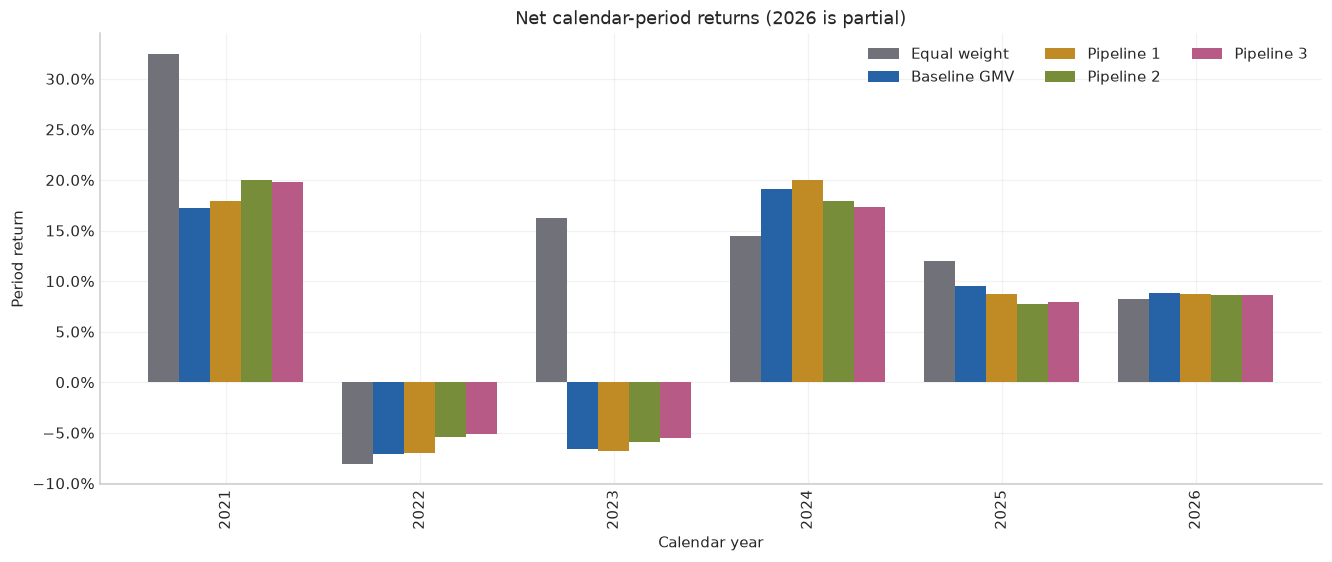

In [9]:
annual = annual_metrics(results)
annual.to_csv(ROOT / "artifacts/tables/comparison_annual_metrics.csv", index=False)
display(annual.pivot(index="year", columns="strategy", values="return").style.format("{:.2%}"))
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
pivot = annual.pivot(index="year", columns="strategy", values="return").reindex(columns=list(LABELS))
pivot.rename(columns=LABELS).plot.bar(ax=ax, color=[COLORS[x] for x in LABELS], width=.8)
ax.set(title="Net calendar-period returns (2026 is partial)", ylabel="Period return", xlabel="Calendar year")
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(ncol=3)
save(fig, "comparison_annual_returns")

### Trading costs and forecast regimes

In [10]:
costs = cost_sensitivity(results)
display(styled(costs.set_index(["cost_bps", "strategy"])[["CAGR", "Sharpe", "CVaR 95%"]]))
conditional = regime_conditioned(results)
display(styled(conditional.set_index(["regime", "strategy"])))

,,CAGR,Sharpe,CVaR 95%
cost_bps,strategy,,,
0,equal_weight,14.18%,0.911,2.23%
10,equal_weight,14.08%,0.906,2.24%
25,equal_weight,13.94%,0.898,2.24%
50,equal_weight,13.71%,0.885,2.24%
0,baseline,8.05%,0.726,1.66%
10,baseline,7.45%,0.678,1.66%
25,baseline,6.55%,0.605,1.66%
50,baseline,5.06%,0.484,1.66%
0,pipeline1,8.19%,0.738,1.66%


,,days,Annualized Volatility,Sharpe,CVaR 95%
regime,strategy,,,,
Calm forecast,equal_weight,620.000,12.08%,1.000,1.71%
Stress forecast,equal_weight,669.000,18.84%,0.883,2.60%
Calm forecast,baseline,620.000,8.99%,0.838,1.28%
Stress forecast,baseline,669.000,13.56%,0.601,1.89%
Calm forecast,pipeline1,620.000,8.96%,0.873,1.27%
Stress forecast,pipeline1,669.000,13.56%,0.595,1.89%
Calm forecast,pipeline2,620.000,8.84%,0.826,1.25%
Stress forecast,pipeline2,669.000,13.55%,0.674,1.87%
Calm forecast,pipeline3,620.000,8.81%,0.815,1.25%


### Is the quality effect specific to company information?

The following **post-evaluation explanatory diagnostics** do not change the frozen settings. A neutral quality score of 0.5 applies the same form of diagonal regularization without ranking businesses. For the ML layer, historical downside risk replaces the learned forecast at the same selected strength. These controls help separate added information from the effect of adding any positive diagonal penalty; they are not independent confirmatory tests.

In [11]:
c = prepare_features(prepare_fundamentals(prepare_context()))
verify_frozen(c, spec)
neutral = c["fundamentals"].copy(); neutral["quality_score"] = .5
neutral_result = strategy({**c, "fundamentals": neutral}, "test", "pipeline2", spec["quality_strength"])
historical_predictions = pd.read_csv(ROOT / "artifacts/tables/pipeline3_test_predictions.csv", parse_dates=["date"])
historical_predictions["predicted_downside_variance"] = historical_predictions.downside_63
historical_result = strategy(c, "test", "pipeline3", spec["quality_strength"], historical_predictions, spec["ml"]["ml_strength"])
controls = {"Pipeline 1": results["pipeline1"], "Neutral diagonal penalty": neutral_result,
            "Quality penalty": results["pipeline2"], "Quality + historical downside": historical_result, "Quality + CatBoost": results["pipeline3"]}
control_table = metric_table(controls)
display(styled(control_table[METRIC_COLUMNS]))
control_table.to_csv(ROOT / "artifacts/tables/test_explanatory_controls.csv")
quality = c["fundamentals"].pivot(index="date", columns="ticker", values="quality_score")
quality_exposure = pd.Series({name: (r.target_weights*quality.reindex(r.target_weights.index)).sum(axis=1).mean() for name,r in results.items()}, name="average_weighted_quality")
display(quality_exposure.to_frame().style.format("{:.3f}"))

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
Pipeline 1,7.55%,11.58%,0.687,0.969,20.72%,1.66%,2.63%,5.946,21.859
Neutral diagonal penalty,8.11%,11.53%,0.734,1.037,18.87%,1.65%,2.63%,5.169,32.597
Quality penalty,7.88%,11.52%,0.716,1.012,19.23%,1.64%,2.61%,5.182,32.038
Quality + historical downside,7.89%,11.47%,0.720,1.017,19.16%,1.63%,2.61%,4.993,34.605
Quality + CatBoost,7.91%,11.49%,0.720,1.018,18.91%,1.64%,2.61%,5.034,34.108


,average_weighted_quality
equal_weight,0.501
baseline,0.508
pipeline1,0.509
pipeline2,0.515
pipeline3,0.514


### Does broader information improve the CatBoost model?

In [12]:
feature_ablations = {name: load_result("pipeline3_"+name, "test") for name in ["price_regime", "plus_fundamentals"]}
feature_ablations["full"] = results["pipeline3"]
display(styled(metric_table(feature_ablations)[METRIC_COLUMNS]))
forecast_rows=[]
for name in ["price_regime", "plus_fundamentals", "full"]:
    path = ROOT / ("artifacts/tables/pipeline3_test_predictions.csv" if name=="full" else f"artifacts/tables/ablation_{name}_test_predictions.csv")
    pred = pd.read_csv(path, parse_dates=["date"])
    forecast_rows.append(prediction_diagnostics(pred).loc["CatBoost"].rename(name))
forecast_table = pd.DataFrame(forecast_rows)
display(forecast_table)
forecast_table.to_csv(ROOT / "artifacts/tables/test_forecast_feature_ablation.csv")

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
price_regime,7.90%,11.50%,0.719,1.016,18.91%,1.64%,2.61%,5.029,34.121
plus_fundamentals,7.91%,11.50%,0.720,1.018,18.91%,1.64%,2.61%,5.027,34.161
full,7.91%,11.49%,0.720,1.018,18.91%,1.64%,2.61%,5.034,34.108


,rows,months,log_risk_RMSE,mean_monthly_rank_IC,median_monthly_rank_IC
price_regime,19703.0,61.0,0.880496,0.532406,0.554008
plus_fundamentals,19703.0,61.0,0.885786,0.532529,0.552069
full,19703.0,61.0,0.892727,0.531878,0.555328


## Takeaways

### Evidence-backed article storyline

In [13]:
b,p1,p2,p3=[test_table.loc[x] for x in ["baseline","pipeline1","pipeline2","pipeline3"]]
display(Markdown(f"""
1. **Start with a strong control.** Shrinkage GMV has {b['Annualized Volatility']:.2%} volatility versus {test_table.loc['equal_weight','Annualized Volatility']:.2%} for equal weighting, with a return trade-off.
2. **Market regimes change the dependence estimate.** Pipeline 1 delivers {p1['CAGR']:.2%} CAGR and a {p1['Sharpe']:.3f} Sharpe ratio; its risk changes are modest and turnover is higher.
3. **Corporate-quality regularization changes portfolio structure.** Pipeline 2 raises effective breadth from {p1['Average Effective Assets']:.2f} to {p2['Average Effective Assets']:.2f} and lowers annual turnover from {p1['Annualized Turnover']:.2f} to {p2['Annualized Turnover']:.2f}. Its CAGR falls to {p2['CAGR']:.2%}; slight tail-risk improvements are insufficient to claim universal dominance. Check the neutral-penalty control before attributing the whole effect to fundamentals.
4. **Better forecasts have limited allocation value here.** Pipeline 3 has {p3['Annualized Volatility']:.2%} volatility and {p3['CVaR 95%']:.2%} daily CVaR95. Its incremental changes relative to Pipeline 2 are small. Feature ablations and prediction diagnostics explain whether the added information affects forecasts, weights, or both.
5. **The conclusion is conditional.** This study supports an incremental experimental framework, not a guaranteed improvement from adding features. Sector-aware quality, a broader historical constituent universe, validated corporate-action data, realistic execution delays and a fresh forward holdout are the next research priorities.
"""))
print("All primary result paths reconciled; use these tables instead of mixing old validation and test numbers.")


1. **Start with a strong control.** Shrinkage GMV has 11.59% volatility versus 15.95% for equal weighting, with a return trade-off.
2. **Market regimes change the dependence estimate.** Pipeline 1 delivers 7.55% CAGR and a 0.687 Sharpe ratio; its risk changes are modest and turnover is higher.
3. **Corporate-quality regularization changes portfolio structure.** Pipeline 2 raises effective breadth from 21.86 to 32.04 and lowers annual turnover from 5.95 to 5.18. Its CAGR falls to 7.88%; slight tail-risk improvements are insufficient to claim universal dominance. Check the neutral-penalty control before attributing the whole effect to fundamentals.
4. **Better forecasts have limited allocation value here.** Pipeline 3 has 11.49% volatility and 1.64% daily CVaR95. Its incremental changes relative to Pipeline 2 are small. Feature ablations and prediction diagnostics explain whether the added information affects forecasts, weights, or both.
5. **The conclusion is conditional.** This study supports an incremental experimental framework, not a guaranteed improvement from adding features. Sector-aware quality, a broader historical constituent universe, validated corporate-action data, realistic execution delays and a fresh forward holdout are the next research priorities.


## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): every ticker with complete coverage of all 6,573 source dates is retained. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.